In [116]:
import numpy as np
import matplotlib.pyplot as plt

In [117]:
def aceleracao(v, m, b, c, g=9.81):
    '''A função recebe os argumentos e retorna o vetor aceleração
    v: vetor velocidade (m/s)
    m: massa (kg)
    g: constante gravitacional (m/s²)
    b: coefienciente linear (kg/s)
    c: coeficiente quadrático(kg/m)

    retorna:
    a: vetor aceleração (m/s²)

    '''

    v_norma = np.linalg.norm(v)
    gravidade = np.array([0,-g]) # 0 no eixo x e "-g" no eixo y
    r_linear = -(b/m) * v
    r_quad = - (c/m)* v_norma * v

    a = gravidade + r_linear + r_quad
    return a

In [118]:

def euler(funcao_acel, r0, v0, t_array, m, b, c, g=9.81):
    '''A função recebe a função taxa, e os parâmetros e retorna os valores de v e r'''

    n = len(t_array)

    r = np.zeros((n, 2)) 
    v = np.zeros((n, 2))
    
    r[0] = r0
    v[0] = v0
    
    for i in range(0, n - 1):
        dt = t_array[i+1] - t_array[i]
        a_atual = funcao_acel(v[i], m, b, c, g)
        r[i+1] = r[i] + v[i] * dt
        v[i+1] = v[i] + a_atual * dt
        
    return r, v

Simulações e Gráficos de Trajetória

In [119]:
# Configurações
m_leve = 0.01 #kg
m_pesado = 0.5 #kg
theta = np.deg2rad(45) # Graus para radianos
v_baixa = 10 #m/s
v_alta = 40 #m/s
t = np.linspace(0,10,5000) #s

b = 0.003
c = 0.005

r0 = np.array([0.0,0.0]) # Posição inicial 0i+0j
v0_baixa = np.array([v_baixa*np.cos(theta),v_baixa*np.sin(theta)]) # Velocidade Inicial Baixa 10cos(theta)i + 10sen(theta)j
v0_alta= np.array([v_alta*np.cos(theta),v_alta*np.sin(theta)]) # Velocidade Inicial Alta 40cos(theta)i + 40sen(theta)j

ESCOLHA DE COEFICIENTES:

$b = 0,003$ kg/s :
    Baseado na Lei de Stokes, onde b = $b = 6\pi\eta r$. Onde $\eta$ é viscosidade do ar, e $r$ é o raio da esfera. Onde consideramos o projétil como uma pequena esfera.


$c = 0,005$ kg/m :
    Baseado na equação de arrasto $c = \frac{1}{2} \rho C_d A$. Onde $\rho$ é a densidade do ar, $C_d$ é o coeficiente de arrasto para uma esfera, $A$ é a área frontal.



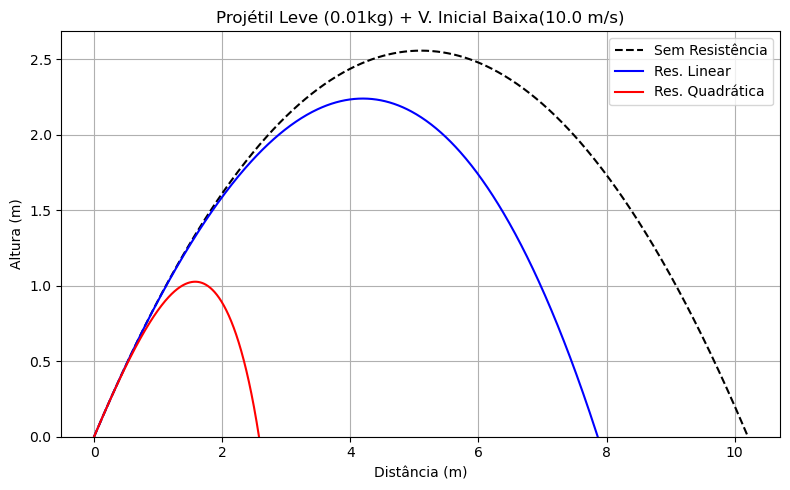

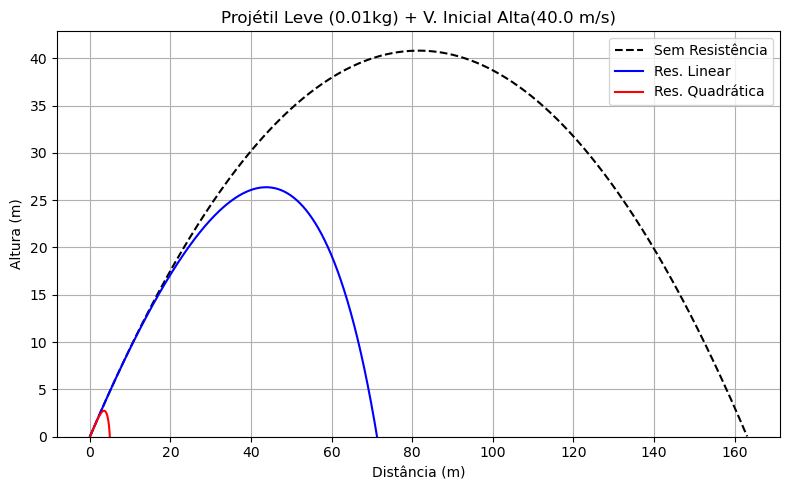

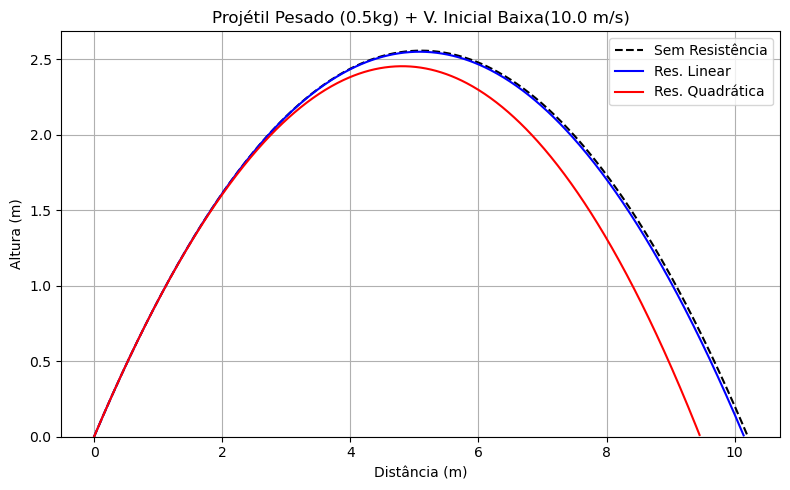

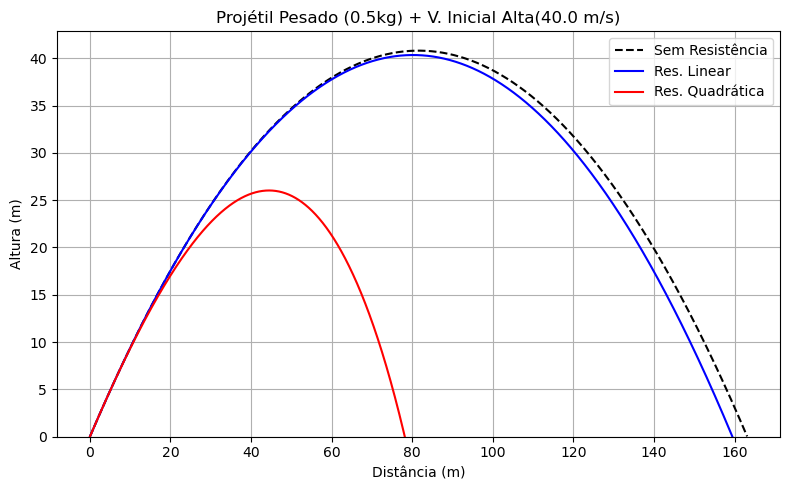

In [ ]:
velocidades = [v0_baixa, v0_alta]
massas = [m_leve, m_pesado]

for m in massas:
    for v in velocidades:
        traj_a, va = euler(aceleracao, r0, v, t, m, 0, 0) # Sem resistência
        traj_b, vb= euler(aceleracao, r0, v, t, m, b, 0) # Resistência Linear
        traj_c, vc = euler(aceleracao, r0, v, t, m, 0, c) # Resistência Quadrática
       
        plt.figure(figsize=(8, 5))
        
        resultados = [
            (traj_a, 'Sem Resistência', 'k--'),
            (traj_b, 'Res. Linear', 'b-'),
            (traj_c, 'Res. Quadrática', 'r-')
        ]

        for traj, nome, estilo in resultados:
            lim_chao = traj[:, 1] >= 0
            plt.plot(traj[lim_chao, 0], traj[lim_chao, 1], estilo, label=nome)


        v_label = "Alta" if np.linalg.norm(v) == 40 else "Baixa"
        m_label = "Leve" if m == 0.01 else "Pesado"
        
        plt.title(f"Projétil {m_label} ({m}kg), V. Inicial {v_label}({np.linalg.norm(v)} m/s)")
        plt.xlabel("Distância (m)")
        plt.ylabel("Altura (m)")
        plt.legend()
        plt.grid()
        plt.ylim(bottom=0) 
        plt.tight_layout()
        
        plt.show()







ANÁLISE

Podemos verificar que os coeficientes podem mudar drásticamente a trajetória do projétil, principalmente no caso do Projétil Leve com velocidade inicial alta, logo simulações que desconsideram tais coeficientes podem ser não condizentes com a realidade.

Caso Projétil Leve, Velocidade Baixa:

Apesar do domínio da resistência quadrática, vemos que não existe uma grande diferença na distância alcançada pelo projétil. Isso acontece pois em velocidades baixas, o termo $|\vec{v}| \vec{v}$ nao cresce tão drasticamente em relação ao termo linear.

Caso Projétil Leve, Velocidade Alta:
    
Com uma alta velocidade o termo $|\vec{v}| \vec{v}$ domina a função, ou seja, o coeficiente quadrático é amplamente dominante.

Caso Projétil Pesado, Velocidade Baixa:

A massa maior do projétil o torna menos suscetível as resistências, fazendo com que as trajetórias sejam mais próximas. Verificamos um domínio maior da gravidade atuando no eixo y, devio ao termo "$-mg$"

Caso Projétil Pesado, Velocidade Alta:
    
O termo $|\vec{v}| \vec{v}$ domina novamente, devido a alta velocidade. Mas podemos ver que a massa maior atenua o efeito do coeficiente quadrático, portanto o domínio do dessa resistência é menor em relação ao caso do projétil leve com baixa velocidade

